## Imports

In [6]:
from pprint import pprint 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import shap
import shapiq
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_curve,
    roc_auc_score,
    auc,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    f1_score,
    brier_score_loss, 
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Functions

In [7]:
# from sklearn.metrics import (
#     accuracy_score,
#     roc_auc_score,
#     average_precision_score,
#     f1_score,
#     classification_report,
#     confusion_matrix,
#     ConfusionMatrixDisplay
# )
# import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, labels_list=None, cm_normalize=None):
    """
    Evaluate a binary classification model with multiple metrics and plots.

    Args:
        model: Fitted scikit-learn model with predict() and predict_proba().
        X_test (array-like): Test feature matrix.
        y_test (array-like): True labels for the test set.
        labels_list (LabelEncoder, optional): If provided, class names are them; 
            otherwise defaults to ["Class 0", "Class 1, ..."].
        cm_normalize (str or None): Normalization method for confusion matrix.
            Options: None, 'true', 'pred', 'all'.
            Default: None (no normalization).

    Prints:
        - Accuracy, Balanced Accuracy
        - ROC AUC (single value)
        - PR AUC (class 0, class 1, macro, micro, weighted)
        - F1 Score (binary, macro, micro, weighted, per class)
        - Precision (macro, micro, weighted, per class)
        - Recall (macro, micro, weighted, per class)
        - Brier Score Loss
        - Log Loss
        - Classification report

    Displays:
        - Confusion matrix (normalized by predicted labels).
    """

    sns.reset_defaults()
    
    if labels_list is None:
        labels = ["Class " + str(i) for i in range(len(set(y_test)))]
    else:
        labels = labels_list

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # --- Base metrics ---
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # --- ROC AUC (single value) ---
    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

    # --- PR AUC variations ---
    pr_auc_class1 = average_precision_score(y_test, y_pred_proba[:, 1])
    pr_auc_class0 = average_precision_score(1 - y_test, y_pred_proba[:, 0])
    pr_auc_macro = np.mean([pr_auc_class0, pr_auc_class1])
    pr_auc_micro = average_precision_score(y_test, y_pred_proba[:, 1], average="micro")
    pr_auc_weighted = (
        pr_auc_class0 * np.mean(y_test == 0) +
        pr_auc_class1 * np.mean(y_test == 1)
    )

    # --- F1 scores ---
    f1_binary = f1_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    f1_per_class = f1_score(y_test, y_pred, average=None)

    # --- Precision ---
    precision_macro = precision_score(y_test, y_pred, average="macro")
    precision_micro = precision_score(y_test, y_pred, average="micro")
    precision_weighted = precision_score(y_test, y_pred, average="weighted")
    precision_per_class = precision_score(y_test, y_pred, average=None)

    # --- Recall ---
    recall_macro = recall_score(y_test, y_pred, average="macro")
    recall_micro = recall_score(y_test, y_pred, average="micro")
    recall_weighted = recall_score(y_test, y_pred, average="weighted")
    recall_per_class = recall_score(y_test, y_pred, average=None)

    # --- Calibration & loss metrics ---
    brier = brier_score_loss(y_test, y_pred_proba[:, 1])
    logloss = log_loss(y_test, y_pred_proba)

    # --- Print metrics ---
    print("===== Evaluation Metrics =====")
    print(f"Accuracy:              {accuracy:.4f}")
    print(f"Balanced Accuracy:     {balanced_acc:.4f}")
    print(f"ROC AUC:               {roc_auc:.4f}")
    print("\n--- PR AUC ---")
    print(f"PR AUC (micro):        {pr_auc_micro:.4f}")
    print(f"PR AUC (macro):        {pr_auc_macro:.4f}")
    print(f"PR AUC (weighted):     {pr_auc_weighted:.4f}")
    print(f"PR AUC (class 0):      {pr_auc_class0:.4f}")
    print(f"PR AUC (class 1):      {pr_auc_class1:.4f}")
    print("\n--- F1-Scores ---")
    print(f"F1-Score (micro):            {f1_micro:.4f}")
    print(f"F1-Score (macro):            {f1_macro:.4f}")
    print(f"F1-Score (weighted):         {f1_weighted:.4f}")
    print(f"F1-Score (class 0):          {f1_per_class[0]:.4f}")
    print(f"F1-Score (class 1):          {f1_per_class[1]:.4f}")
    print("\n--- Precision ---")
    print(f"Precision (micro):     {precision_micro:.4f}")
    print(f"Precision (macro):     {precision_macro:.4f}")
    print(f"Precision (weighted):  {precision_weighted:.4f}")
    print(f"Precision (class 0):   {precision_per_class[0]:.4f}")
    print(f"Precision (class 1):   {precision_per_class[1]:.4f}")
    print("\n--- Recall ---")
    print(f"Recall (micro):        {recall_micro:.4f}")
    print(f"Recall (macro):        {recall_macro:.4f}")
    print(f"Recall (weighted):     {recall_weighted:.4f}")
    print(f"Recall (class 0):      {recall_per_class[0]:.4f}")
    print(f"Recall (class 1):      {recall_per_class[1]:.4f}")
    print("\n--- Loss Metrics ---")
    print(f"Brier Score Loss:      {brier:.4f}")
    print(f"Log Loss:              {logloss:.4f}\n")

    # --- Classification report ---
    print("===== Classification Report =====")
    print(classification_report(y_test, y_pred, target_names=labels))

    # --- Confusion Matrix ---
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred, normalize=cm_normalize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)

    im = ax.images[0]
    im.set_clim(0, 1 if cm_normalize else cm.max())
    fig.colorbar(im, ax=ax)

    plt.title(f"Confusion Matrix")
    plt.xticks(rotation=45)
    plt.show()


## Configurations

In [8]:
# --- Article Style Configuration ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'mathtext.fontset': 'cm' # Use Computer Modern for math (LaTeX style)
})


## Loading Data

In [10]:
df = pd.read_pickle("../data/processed/GFA_binary_processed.pkl.zip", compression="zip")
display(df)
column_levels = df.columns.get_level_values(0)
column_counts = column_levels.value_counts()

print(column_counts)

compounds                                                        ...  \
             Ag Ag2MoO4   Ag2O Ag2S Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
0      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
1      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
2      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
3      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
4      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...    ...  ...   ...   ...    ...  ...  ...  ...  ...   
51617  0.546000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51618  0.000000     0.0  0.906  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51619  0.598000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51620  0.602000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51621  0.666334     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   

      GS_parameters                                                        \
              Kw_Tx     Kw_Tc     Kh_Tc      H_Tx  gamma_Tc        jezica   
0          0.053885  0.277478  1.114669  0.113780  0.509686  1.337509e-05   
1          0.047302  0.299266  1.382359  0.097682  0.527885  1.830552e-05   
2          0.042967  0.104088  0.249421  0.089777  0.394079  1.643464e-05   
3          0.161115  0.139911  0.541528  0.267755  0.463024  3.667110e-03   
4          0.166038  0.153593  0.644383  0.273067  0.473644  4.272496e-03   
...             ...       ...       ...       ...       ...           ...   
51617      0.032749  0.143965  0.479901  0.058896  0.449865  5.968752e-06   
51618      0.031069  0.024906  0.043386  0.077475  0.304013  1.085713e-06   
51619      0.014055  0.105325  0.278355  0.027223  0.409959  2.689811e-06   
51620      0.052798  0.081111  0.161702  0.126528  0.351654  1.325418e-06   
51621     -0.054656  0.054898  0.099329 -0.139281  0.321250  2.203795e-07   

           metadata              sample_id   target  
      num_compounds num_elements       Kod       GF  
0                 2            2     26356  Crystal  
1                 2            2     26356  Crystal  
2                 2            2     27653  Crystal  
3                 3            3     26356  Crystal  
4                 3            3     26356  Crystal  
...             ...          ...       ...      ...  
51617             3            3     27768  Crystal  
51618             3            4     36491  Crystal  
51619             3            3     27768  Crystal  
51620             3            3     27768  Crystal  
51621             2            2     27768  Crystal  

[50897 rows x 919 columns]

compounds              313
weighted_properties    265
absolute_properties    264
elements                67
GS_parameters            6
metadata                 2
sample_id                1
target                   1
Name: count, dtype: int64


In [11]:
df.describe()

compounds                                                          \
                 Ag       Ag2MoO4          Ag2O          Ag2S         Ag2Se   
count  50897.000000  50897.000000  50897.000000  50897.000000  50897.000000   
mean       0.001610      0.000203      0.003449      0.003641      0.001352   
std        0.019304      0.009475      0.033855      0.039230      0.021535   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000      0.000000   
max        0.666334      0.741000      0.906000      0.810000      0.619000   

                                                                             \
              Ag2Te        Ag4SSe          AgBr          AgCl           AgF   
count  50897.000000  50897.000000  50897.000000  50897.000000  50897.000000   
mean       0.000063      0.000127      0.000370      0.000727      0.000417   
std        0.004510      0.005623      0.012895      0.017818      0.014387   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000      0.000000   
max        0.545900      0.395000      0.708000      0.800000      0.698000   

       ... weighted_properties GS_parameters                              \
       ...          W|zeff|sum         Kw_Tx         Kw_Tc         Kh_Tc   
count  ...        50897.000000  50897.000000  50897.000000  50897.000000   
mean   ...            4.749015      0.116085      0.136201      1.131094   
std    ...            0.883316      0.079954      0.078811    242.192859   
min    ...            2.736398     -0.401324     -0.459414 -15442.039884   
25%    ...            4.115135      0.066196      0.087218      0.265039   
50%    ...            4.512600      0.107516      0.131351      0.533896   
75%    ...            5.173036      0.156758      0.179038      0.980433   
max    ...            7.405000      0.582487      0.683675  49189.618627   

                                                     metadata                \
               H_Tx      gamma_Tc        jezica num_compounds  num_elements   
count  50897.000000  50897.000000  5.056800e+04  50897.000000  50897.000000   
mean       0.189913      0.468722  7.431631e+00      2.898835      3.920094   
std        0.140388      0.058823  5.267492e+02      0.303110      0.658028   
min       -0.333333      0.166612  2.010870e-12      1.000000      1.000000   
25%        0.105170      0.434096  5.341181e-06      3.000000      4.000000   
50%        0.169510      0.469712  2.992463e-05      3.000000      4.000000   
75%        0.251866      0.504096  2.715772e-04      3.000000      4.000000   
max        1.399841      0.806007  7.446676e+04      3.000000      8.000000   

          sample_id  
                Kod  
count  50897.000000  
mean   26587.654518  
std     6140.811357  
min    20948.000000  
25%    22321.000000  
50%    23427.000000  
75%    28629.000000  
max    44875.000000  

[8 rows x 918 columns]

In [ ]:
df_num = df.select_dtypes(include="number")

group_order = [
    "elements",
    "GS_parameters",
    "weighted_properties",
    "absolute_properties",
]

# Selected property features
selected_properties = [
    'A|vdw_radius_uff|std',
    'W|atomic_radius_rahm|mean',
    'W|NpValence|mean',
    'A|pettifor_number|sum',
    'W|FusionEnthalpy|sum',
    'W|num_oxistates|mean',
    'A|FusionEnthalpy|mean',
    'W|NdValence|mean',
    'W|NsValence|sum',
    'A|GSbandgap|std',
    'W|GSvolume_pa|mean',
    'W|GSbandgap|sum',
    'A|num_oxistates|std',
    'W|NdUnfilled|max',
    'W|NpUnfilled|sum',
    'A|melting_point|std',
    'A|NUnfilled|sum',
    'A|num_oxistates|max',
    'W|covalent_radius_cordero|std',
    'A|en_Martynov_Batsanov|std',
]

groups = df_num.columns.get_level_values(0)
features = df_num.columns.get_level_values(1)
mask = (
    (groups.isin(["elements", "GS_parameters"])) |
    (
        groups.isin(["weighted_properties", "absolute_properties"]) &
        features.isin(selected_properties)
    )
)

df_num = df_num.loc[:, mask]
desc = df_num.describe(percentiles=[0.25, 0.5, 0.75]).T

desc["Group"] = df_num.columns.get_level_values(0)
desc["Feature"] = df_num.columns.get_level_values(1)

# Select and rename columns
desc = desc[
    ["Feature", "Group", "min", "max", "mean", "std", "50%", "25%", "75%"]
].rename(
    columns={
        "min": "Min",
        "max": "Max",
        "mean": "Mean",
        "std": "Std",
        "50%": "Median",
        "25%": "Q25",
        "75%": "Q75",
    }
)

# Order groups
desc["Group"] = pd.Categorical(
    desc["Group"],
    categories=group_order,
    ordered=True
)

desc = desc.sort_values(["Group", "Feature"]).reset_index(drop=True)
desc['Group'] = desc['Group'].astype(str).replace('elements', 'CHEM').astype('category')


desc[["Min", "Max", "Mean", "Std", "Median", "Q25", "Q75"]] = (
    desc[["Min", "Max", "Mean", "Std", "Median", "Q25", "Q75"]]
    .astype(float)
    .round(4)
)

desc.to_excel("../data/support/analysis_table/feature_statistics.xlsx", index=False)

# Convert to Markdown
markdown_table = desc.to_markdown(
    index=False,
    tablefmt="github"
)

with open('../data/support/analysis_table/feature_statistics.txt', 'w') as f:
    f.write(markdown_table)

print(markdown_table)


| Feature                       | Group               |         Min |        Max |     Mean |      Std |   Median |      Q25 |      Q75 |
|-------------------------------|---------------------|-------------|------------|----------|----------|----------|----------|----------|
| Ag                            | CHEM                |      0      |     0.6663 |   0.0108 |   0.0542 |   0      |   0      |   0      |
| Al                            | CHEM                |      0      |     0.4    |   0.0085 |   0.0329 |   0      |   0      |   0      |
| As                            | CHEM                |      0      |     0.8829 |   0.0215 |   0.0848 |   0      |   0      |   0      |
| B                             | CHEM                |      0      |     0.695  |   0.0498 |   0.1006 |   0      |   0      |   0      |
| Ba                            | CHEM                |      0      |     0.391  |   0.0104 |   0.0341 |   0      |   0      |   0      |
| Be                            | 

In [30]:
missing_rows = df[df.isnull().any(axis=1)]
display(missing_rows)


compounds                                                      ...  \
             Ag Ag2MoO4 Ag2O Ag2S Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
96        0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
273       0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
307       0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
911       0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
918       0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...  ...  ...   ...   ...    ...  ...  ...  ...  ...   
50730     0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
50768     0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51267     0.000     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51344     0.396     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51384     0.404     0.0  0.0  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   

      GS_parameters                                                 \
              Kw_Tx     Kw_Tc     Kh_Tc      H_Tx  gamma_Tc jezica   
96         0.120088  0.006628  0.014093  0.229588  0.347778    NaN   
273        0.123475  0.040380  0.092572  0.235903  0.370087    NaN   
307        0.235972  0.046168  0.094930  0.504755  0.350028    NaN   
911        0.098448  0.044032  0.084345  0.226880  0.333320    NaN   
918        0.114576  0.053437  0.111656  0.244834  0.355191    NaN   
...             ...       ...       ...       ...       ...    ...   
50730      0.058668  0.062518  0.156678  0.108956  0.390635    NaN   
50768      0.049820  0.058127  0.144741  0.092211  0.388504    NaN   
51267      0.033215  0.062167  0.119124  0.079850  0.337673    NaN   
51344      0.033209  0.109603  0.315541  0.061152  0.422962    NaN   
51384      0.030709  0.105308  0.296345  0.056939  0.418781    NaN   

           metadata              sample_id   target  
      num_compounds num_elements       Kod       GF  
96                2            3     35879  Crystal  
273               2            3     25415  Crystal  
307               2            2     25767  Crystal  
911               3            4     21390  Crystal  
918               3            4     21390    Glass  
...             ...          ...       ...      ...  
50730             3            5     23697    Glass  
50768             3            5     23696    Glass  
51267             3            4     34705  Crystal  
51344             3            3     28199    Glass  
51384             3            3     25772    Glass  

[329 rows x 919 columns]

In [33]:
df[('GS_parameters', 'jezica')].isnull().sum()


np.int64(329)

## Element Analysis

In [34]:
df['elements'].columns

Index(['Ag', 'Al', 'As', 'B', 'Ba', 'Be', 'Bi', 'Br', 'Ca', 'Cd', 'Ce', 'Cl',
       'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge',
       'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn',
       'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'O', 'P', 'Pb', 'Pr', 'Rb', 'S',
       'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Ti', 'Tl',
       'Tm', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr'],
      dtype='object')

In [35]:
elements_list = df['elements'].columns.to_list()
print(f"There are {len(elements_list)} elements: {elements_list}")

compounds_counts = (df['compounds'].round(4) != 0).sum()
sorted_compounds_counts = compounds_counts.sort_values(ascending=False)
print(f"There are {sum(compounds_counts)} compounds (non null)")

elements_counts = (df['elements'].round(4) != 0).sum()
sorted_elements_counts = elements_counts.sort_values(ascending=False)
print(f"There are {sum(elements_counts)} elements (non null)")

classes_count = df[('target', 'GF')].value_counts()
print(f"There are {len(classes_count)} classes: {classes_count.index.to_list()}")

num_compounds_count = df[('metadata', 'num_compounds')].value_counts().sort_index()
num_elements_count = df[('metadata', 'num_elements')].value_counts().sort_index()

There are 67 elements: ['Ag', 'Al', 'As', 'B', 'Ba', 'Be', 'Bi', 'Br', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'O', 'P', 'Pb', 'Pr', 'Rb', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Ti', 'Tl', 'Tm', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']
There are 147417 compounds (non null)
There are 199095 elements (non null)
There are 2 classes: ['Glass', 'Crystal']


/tmp/ipykernel_134835/378779431.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')  # Yellow -> Orange -> Red heatmap


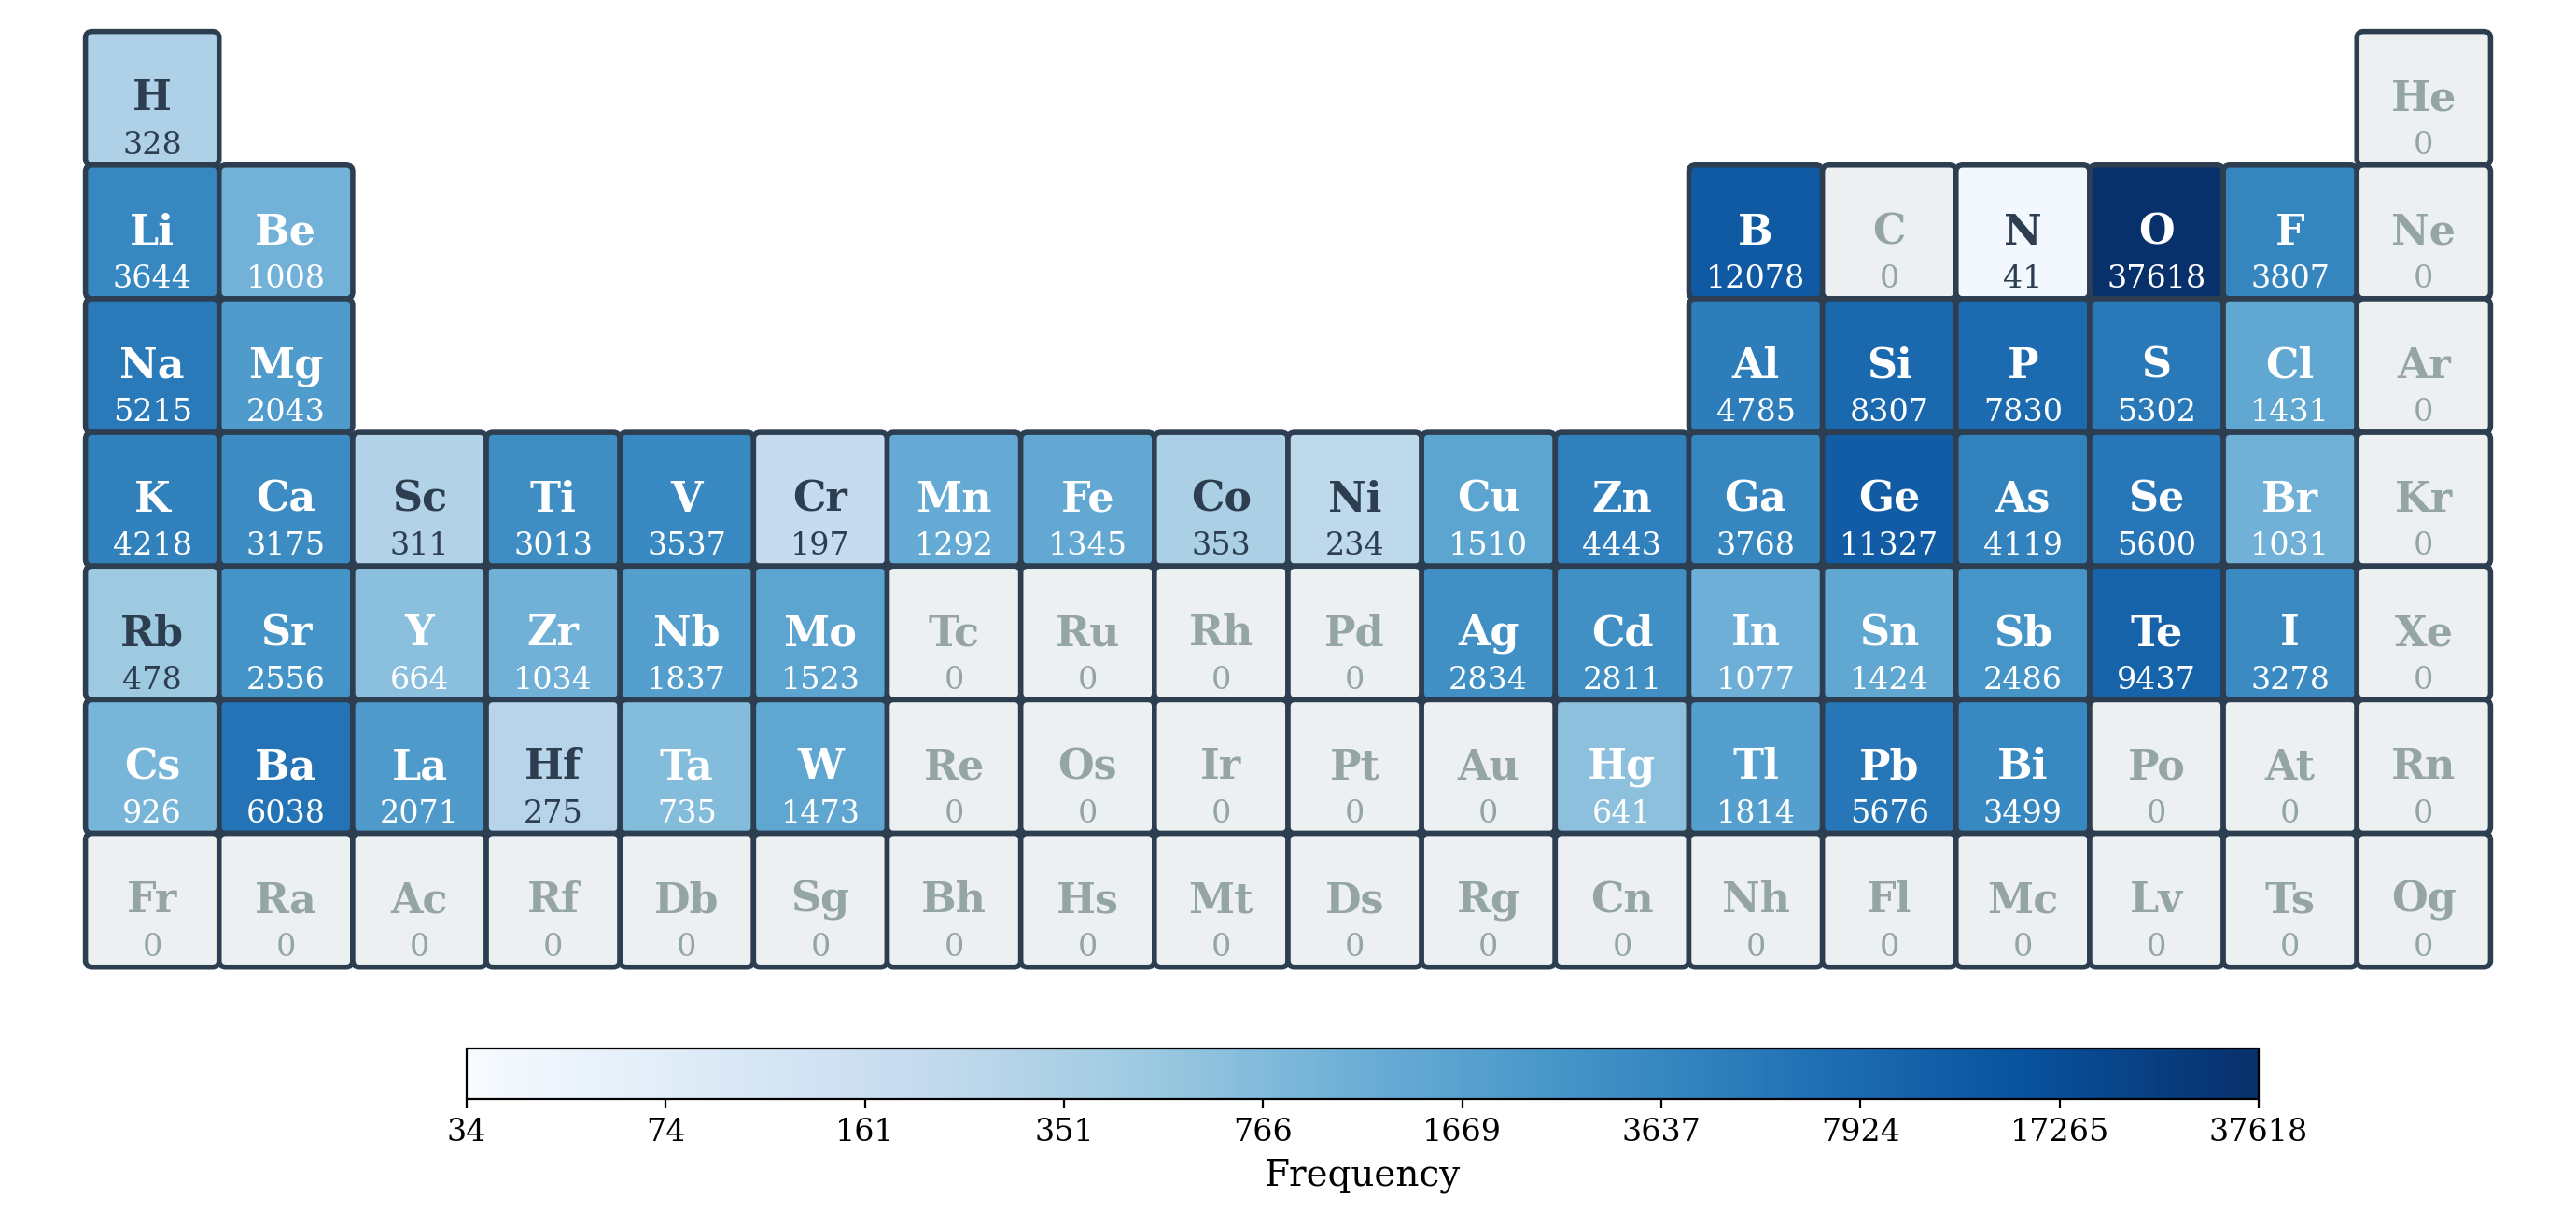

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# Periodic table data
periodic_table_data = {
    'H': (1, 1), 'He': (1, 18),
    'Li': (2, 1), 'Be': (2, 2), 'B': (2, 13), 'C': (2, 14), 'N': (2, 15), 'O': (2, 16), 'F': (2, 17), 'Ne': (2, 18),
    'Na': (3, 1), 'Mg': (3, 2), 'Al': (3, 13), 'Si': (3, 14), 'P': (3, 15), 'S': (3, 16), 'Cl': (3, 17), 'Ar': (3, 18),
    'K': (4, 1), 'Ca': (4, 2), 'Sc': (4, 3), 'Ti': (4, 4), 'V': (4, 5), 'Cr': (4, 6), 'Mn': (4, 7), 'Fe': (4, 8), 'Co': (4, 9), 'Ni': (4, 10), 'Cu': (4, 11), 'Zn': (4, 12), 'Ga': (4, 13), 'Ge': (4, 14), 'As': (4, 15), 'Se': (4, 16), 'Br': (4, 17), 'Kr': (4, 18),
    'Rb': (5, 1), 'Sr': (5, 2), 'Y': (5, 3), 'Zr': (5, 4), 'Nb': (5, 5), 'Mo': (5, 6), 'Tc': (5, 7), 'Ru': (5, 8), 'Rh': (5, 9), 'Pd': (5, 10), 'Ag': (5, 11), 'Cd': (5, 12), 'In': (5, 13), 'Sn': (5, 14), 'Sb': (5, 15), 'Te': (5, 16), 'I': (5, 17), 'Xe': (5, 18),
    'Cs': (6, 1), 'Ba': (6, 2), 'La': (6, 3), 'Hf': (6, 4), 'Ta': (6, 5), 'W': (6, 6), 'Re': (6, 7), 'Os': (6, 8), 'Ir': (6, 9), 'Pt': (6, 10), 'Au': (6, 11), 'Hg': (6, 12), 'Tl': (6, 13), 'Pb': (6, 14), 'Bi': (6, 15), 'Po': (6, 16), 'At': (6, 17), 'Rn': (6, 18),
    'Fr': (7, 1), 'Ra': (7, 2), 'Ac': (7, 3), 'Rf': (7, 4), 'Db': (7, 5), 'Sg': (7, 6), 'Bh': (7, 7), 'Hs': (7, 8), 'Mt': (7, 9), 'Ds': (7, 10), 'Rg': (7, 11), 'Cn': (7, 12), 'Nh': (7, 13), 'Fl': (7, 14), 'Mc': (7, 15), 'Lv': (7, 16), 'Ts': (7, 17), 'Og': (7, 18),
}

# Count elements
element_counts = sorted_elements_counts.to_dict()
max_count = max(element_counts.values()) if element_counts else 1
min_count = min([v for v in element_counts.values() if v > 0], default=1)

# Create logarithmic normalization and colormap
log_norm = Normalize(vmin=np.log10(min_count), vmax=np.log10(max_count))
cmap = cm.get_cmap('Blues')  # Yellow -> Orange -> Red heatmap

fig = plt.figure(figsize=(16, 9), dpi=200, facecolor='white')
ax = fig.add_axes([0.05, 0.15, 0.85, 0.75])

# Draw each element
for element, (row, col) in periodic_table_data.items():
    count = element_counts.get(element, 0)
    
    # Get color from heatmap using log scale
    if count > 0:
        log_count = np.log10(count)
        color = cmap(log_norm(log_count))
        text_color = 'white' if log_count > np.log10(max_count) * 0.6 else '#2c3e50'
    else:
        color = '#ecf0f1' 
        text_color = '#95a5a6'
    
    # Draw rectangle
    rect = mpatches.FancyBboxPatch(
        (col - 0.45, 7.5 - row + 0.45), 0.9, 0.9,
        boxstyle="round,pad=0.05",
        linewidth=2,
        edgecolor='#2c3e50',
        facecolor=color,
        zorder=2
    )
    ax.add_patch(rect)
    
    # Add element symbol
    ax.text(col, 7.5 - row + 0.9, element,
            fontsize=16, fontweight='bold',
            ha='center', va='center',
            color=text_color, zorder=3)
    
    # Add count
    ax.text(col, 7.6 - row + 0.45, str(int(count)),
            fontsize=12,# fontweight='bold',
            ha='center', va='center',
            color=text_color, zorder=3)

# Configure axes
ax.set_xlim(0, 19)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')

# # Add title
# ax.text(9.5, 7.95, 'Periodic Table - Element Occurrence in Dataset (Log Scale)',
#         fontsize=18, fontweight='bold',
#         ha='center', va='top')

# Add colorbar below the table with log labels
cbar_ax = fig.add_axes([0.2, 0.2, 0.6, 0.03])
sm = ScalarMappable(cmap=cmap, norm=log_norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

# Create logarithmic tick labels
log_ticks = np.linspace(np.log10(min_count), np.log10(max_count), 10)
log_labels = [f'{int(10**tick)}' for tick in log_ticks]
cbar.set_ticks(log_ticks)
cbar.set_ticklabels(log_labels)
cbar.set_label('Frequency', fontsize=14)

# # Add legend
# absent_patch = mpatches.Patch(facecolor='#ecf0f1', edgecolor='#2c3e50', label='Not Present')
# ax.legend(handles=[absent_patch],
#           loc='upper right', fontsize=11, framealpha=0.95)

plt.savefig("../reports/figures/periodic_table_element_occurrence_log_scale.png", dpi=300, bbox_inches='tight')
plt.show()

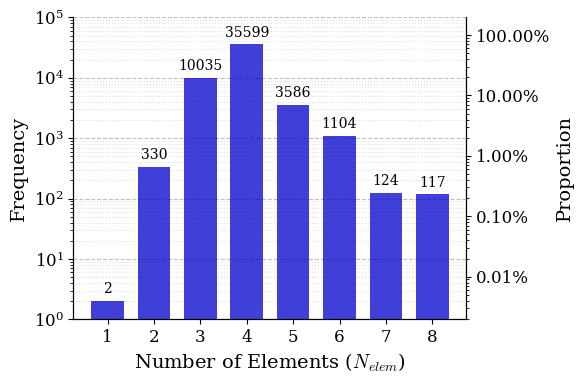

In [47]:
total_count = num_elements_count.sum()

fig, ax = plt.subplots(figsize=(6, 4))

rects = ax.bar(num_elements_count.index, num_elements_count.values, 
               color='mediumblue', alpha=0.75, width=0.7, zorder=3)
ax.set_yscale('log')
y_min, y_max = 10**0, 10**5
ax.set_ylim(y_min, y_max)
ax.set_ylabel('Frequency')
ax.set_xlabel(r'Number of Elements ($N_{elem}$)')

ax2 = ax.twinx()
ax2.set_yscale('log')
ax2.set_ylim(y_min / total_count, y_max / total_count)
ax2.set_ylabel('Proportion')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=2)) # Format the right ticks as percentages

# Grid on the primary axis handles the visual lines for both since they are aligned
ax.grid(axis='y', which='major', linestyle='--', alpha=0.8, zorder=0)
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.4, zorder=0)

# Remove top spine (but keep right spine for the second axis)
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Ensure X-axis shows all integer values present
ax.set_xticks(num_elements_count.index)

# Add Count Labels on Top of Bars
for rect in rects:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height * 1.2, 
            f'{int(height)}', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/num_elements_log_scale.png', dpi=300, bbox_inches='tight')
plt.show()

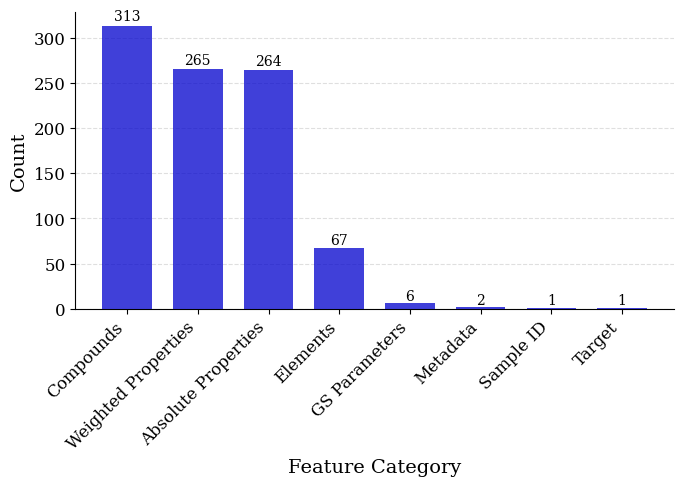

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

formatted_labels = [label.replace('_', ' ').title().replace('Gs', 'GS').replace('Id', 'ID') 
                    for label in column_counts.index]

rects = ax.bar(range(len(column_counts)), column_counts.values, 
               color='mediumblue', alpha=0.75, width=0.7, zorder=3)

# Log Scale
# ax.set_yscale('log')
# ax.set_ylim(0.5, 1000)

ax.set_xlabel('Feature Category') 
ax.set_ylabel('Count')
ax.set_xticks(range(len(column_counts)))
ax.set_xticklabels(formatted_labels, rotation=45, ha='right')
ax.grid(axis='y', which='major', linestyle='--', alpha=0.4, zorder=0)
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, zorder=0)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add Count Labels
for rect in rects:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height * 1.01, 
            f'{int(height)}', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
#plt.savefig('column_types_distribution.png', dpi=300, bbox_inches='tight')
plt.show()